In [1]:
# ANALISIS EXPLORATORIO
#
# NOTA DE EJECUCION: en este equipo se lee desde el fichero exportado
# para visualizacion, que contiene los mismos 886 anuncios ya
# procesados. El conjunto analitico original se regenera con
#   python -m data_ingestion.build_dataset
# y requiere el CSV de origen en data/raw/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

df = pd.read_csv("../data/processed/tableau/tableau_anuncios.csv",
                 sep=";", decimal=",", encoding="utf-8-sig")

# Los nombres de columna del fichero de visualizacion estan en
# castellano; se renombran para mantener el codigo del notebook
df = df.rename(columns={
    "precio_mes": "monthly_price",
    "superficie_m2": "area_sqm",
    "precio_m2": "price_per_sqm",
    "habitaciones": "n_rooms",
    "tipologia": "typology",
    "municipio": "municipality",
})

print(f"{len(df)} anuncios, {len(df.columns)} columnas")
print(f"Columnas: {df.columns.tolist()}")
df.head(3)

886 anuncios, 18 columnas
Columnas: ['listing_id', 'monthly_price', 'area_sqm', 'price_per_sqm', 'n_rooms', 'typology', 'municipality', 'barrio', 'barrio_anuncio', 'confianza_barrio', 'margen_ria', 'dist_centro_m', 'atipico', 'excluido', 'emal_precio_m2', 'emal_renta_media', 'brecha_pct', 'zona']


,listing_id,monthly_price,area_sqm,price_per_sqm,n_rooms,typology,municipality,barrio,barrio_anuncio,confianza_barrio,margen_ria,dist_centro_m,atipico,excluido,emal_precio_m2,emal_renta_media,brecha_pct,zona
0,3,960.0,69.0,13.91,3,flat,Getxo,NaN,NaN,unmapped,derecha,11523.0,False,False,11.63,886.98,19.6,Getxo - sin barrio
1,4,880.0,60.0,14.67,1,flat,Bilbao,Zabalburu-Diputación,Zabalburu-Diputación,excluded,capital,NaN,False,False,NaN,NaN,NaN,Bilbao - Zabalburu-Diputación
2,5,1100.0,85.0,12.94,3,flat,Bilbao,Abando,Abandoibarra-Guggenheim,high,capital,NaN,False,False,14.36,1000.66,-9.9,Bilbao - Abando


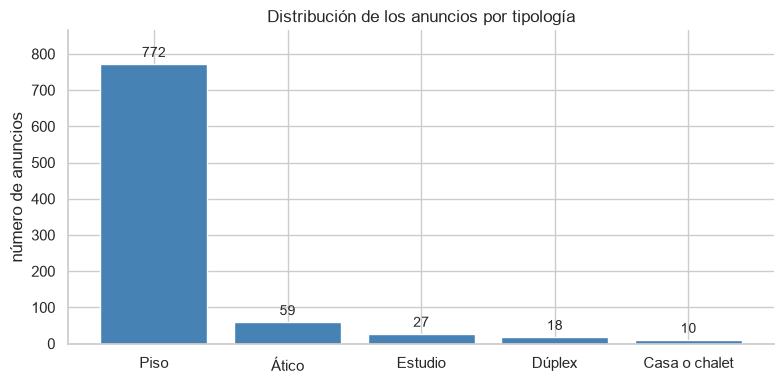

Cifras para corregir el anexo:
  Piso: 772 (87.1 %)
  Ático: 59 (6.7 %)
  Estudio: 27 (3.0 %)
  Dúplex: 18 (2.0 %)
  Casa o chalet: 10 (1.1 %)
  TOTAL: 886


In [2]:
# FIGURA A1.2 — Distribucion de anuncios por tipologia
#
# Barras de recuento. Justifica visualmente por que hubo que agrupar
# las tipologias minoritarias: la concentracion en piso es tan alta
# que el resto no tiene volumen suficiente para modelizar.

conteo = df["typology"].value_counts()

# Nombres en castellano para la figura del anexo
NOMBRES = {"flat": "Piso", "penthouse": "Ático", "studio": "Estudio",
           "duplex": "Dúplex", "house": "Casa o chalet"}
conteo.index = [NOMBRES.get(t, t) for t in conteo.index]

fig, ax = plt.subplots(figsize=(8, 4))
barras = ax.bar(conteo.index, conteo.values, color="steelblue")
ax.bar_label(barras, padding=3, fontsize=10)
ax.set_ylabel("número de anuncios")
ax.set_title("Distribución de los anuncios por tipología")
ax.set_ylim(0, conteo.max() * 1.12)
sns.despine()
plt.tight_layout()
plt.savefig("../docs/figuras/A1_2_tipologia.png", dpi=200, bbox_inches="tight")
plt.show()

print("Cifras para corregir el anexo:")
for t, n in conteo.items():
    print(f"  {t}: {n} ({n/len(df)*100:.1f} %)")
print(f"  TOTAL: {conteo.sum()}")

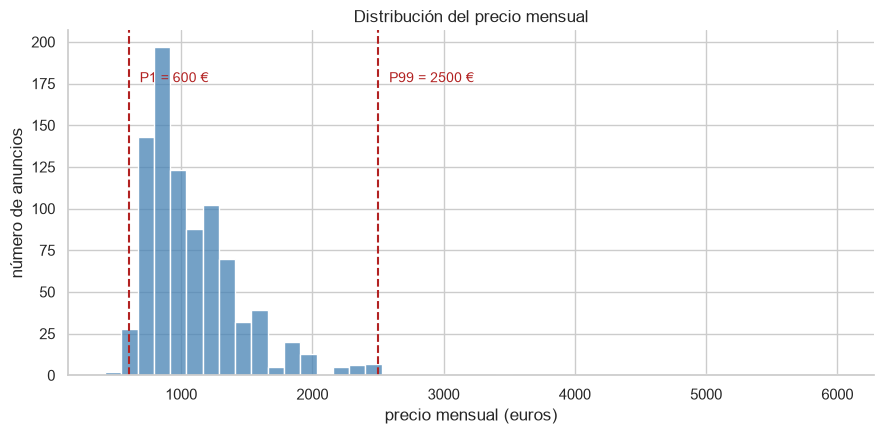

Percentil 1:  600 €
Mediana:      980 €
Percentil 99: 2500 €
Máximo:       6000 €


In [3]:
# FIGURA A1.3 — Distribucion del precio mensual con percentiles 1 y 99
#
# Los percentiles extremos son los umbrales de las reglas de
# consistencia del detector de anomalias. La figura muestra de donde
# salen esos valores.

p01 = df["monthly_price"].quantile(0.01)
p99 = df["monthly_price"].quantile(0.99)

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(df["monthly_price"], bins=45, color="steelblue", ax=ax)

ax.axvline(p01, color="firebrick", linestyle="--", linewidth=1.5)
ax.axvline(p99, color="firebrick", linestyle="--", linewidth=1.5)

ax.annotate(f"P1 = {p01:.0f} €", xy=(p01, ax.get_ylim()[1] * 0.85),
            xytext=(8, 0), textcoords="offset points",
            color="firebrick", fontsize=10)
ax.annotate(f"P99 = {p99:.0f} €", xy=(p99, ax.get_ylim()[1] * 0.85),
            xytext=(8, 0), textcoords="offset points",
            color="firebrick", fontsize=10)

ax.set_xlabel("precio mensual (euros)")
ax.set_ylabel("número de anuncios")
ax.set_title("Distribución del precio mensual")
sns.despine()
plt.tight_layout()
plt.savefig("../docs/figuras/A1_3_precio_percentiles.png",
            dpi=200, bbox_inches="tight")
plt.show()

print(f"Percentil 1:  {p01:.0f} €")
print(f"Mediana:      {df['monthly_price'].median():.0f} €")
print(f"Percentil 99: {p99:.0f} €")
print(f"Máximo:       {df['monthly_price'].max():.0f} €")

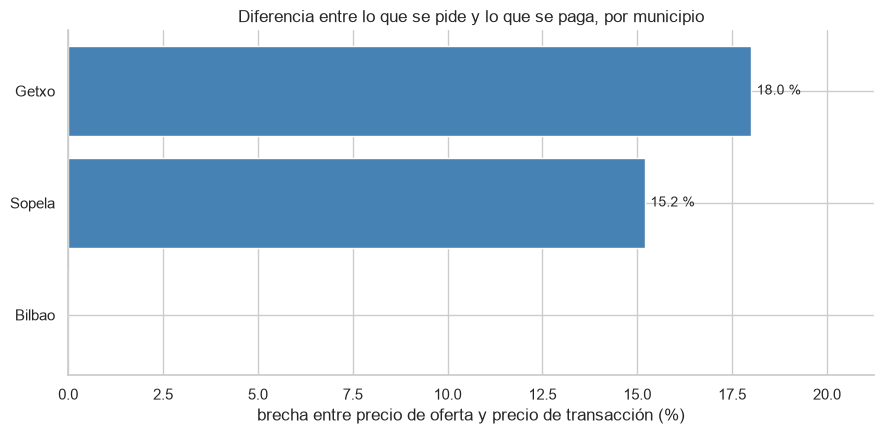

              anuncios  oferta  pagado  brecha
municipality                                  
Bilbao             533   13.36   14.36    -7.0
Sopela              14   11.97   10.39    15.2
Getxo               14   13.72   11.63    18.0


In [5]:
# FIGURA A2.3 — Brecha preliminar por municipio
#
# Compara, para cada municipio con muestra suficiente, el precio
# medio de oferta de los anuncios con el precio de transaccion de
# la estadistica oficial.

resumen = (df[df["emal_precio_m2"].notna()]
           .groupby("municipality")
           .agg(anuncios=("price_per_sqm", "size"),
                oferta=("price_per_sqm", "mean"),
                pagado=("emal_precio_m2", "first"))
           .query("anuncios >= 8")
           .round(2))
resumen["brecha"] = ((resumen["oferta"] - resumen["pagado"])
                     / resumen["pagado"] * 100).round(1)
resumen = resumen.sort_values("brecha", ascending=True)

fig, ax = plt.subplots(figsize=(9, 4.5))
barras = ax.barh(resumen.index, resumen["brecha"], color="steelblue")
ax.bar_label(barras, fmt="%.1f %%", padding=4, fontsize=10)
ax.set_xlabel("brecha entre precio de oferta y precio de transacción (%)")
ax.set_ylabel("")
ax.set_title("Diferencia entre lo que se pide y lo que se paga, por municipio")
ax.set_xlim(0, resumen["brecha"].max() * 1.18)
sns.despine()
plt.tight_layout()
plt.savefig("../docs/figuras/A2_3_brecha_municipio.png",
            dpi=200, bbox_inches="tight")
plt.show()

print(resumen.to_string())

In [8]:
# MODELO DE PREDICCION DE PRECIO
#
# Objetivo: estimar el precio mensual de un alquiler a partir de las
# caracteristicas del inmueble y su localizacion.
#
# Se entrena sobre el LOGARITMO del precio, no sobre el precio directo.
# Motivo: la distribucion tiene cola larga a la derecha (asimetria 3,55)
# y los modelos asumen errores simetricos. Con el logaritmo la
# asimetria baja a 0,89.
#
# Las metricas se reportan en euros, deshaciendo la transformacion.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold, GroupKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
RANDOM_STATE = 42

df = pd.read_parquet("../data/processed/model_dataset.parquet")

NUMERICAS = ["area_sqm", "n_rooms", "sqm_per_room"]
CATEGORICAS = ["typology_grouped", "zona_modelo", "river_bank"]

X = df[NUMERICAS + CATEGORICAS]
y_euros = df["monthly_price"]
y = np.log(y_euros)          # objetivo transformado
grupos = df["zona_modelo"]   # para la validacion agrupada

print(f"{len(df)} registros | {len(NUMERICAS)} numericas | {len(CATEGORICAS)} categoricas")
print(f"Precio: mediana {y_euros.median():.0f} EUR, rango {y_euros.min():.0f}-{y_euros.max():.0f}")

859 registros | 3 numericas | 3 categoricas
Precio: mediana 990 EUR, rango 550-6000
